In [1]:
# ── Cell 0: Imports & Load Results ───────────────────────────────────────────
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
})

# ══════════════════════════════════════════════════════════════════════════════
# HOUSE TYPE — change this one variable to switch between detached and semi
# ══════════════════════════════════════════════════════════════════════════════
import os

HOUSE_TYPE = os.environ.get("HOUSE_TYPE", "detached")   # "detached" or "semi"
ARCHETYPE_LABEL = 'Semi-detached' if HOUSE_TYPE == 'semi' else 'Detached'

_here = Path.cwd().resolve()
_root = _here if (_here / "formal model file" / "output").exists() else _here.parents[2]
OUT_BASE = _root / "formal model file" / "output"
FIG_BASE = OUT_BASE / "figures"
FIG_IN_TEXT_DIR = FIG_BASE / "in_text"
FIG_APPENDIX_DIR = FIG_BASE / "appendix"

if HOUSE_TYPE == "semi":
    RESULTS_CSV = OUT_BASE / "results" / "results_v7_semi.csv"
    MODEL_DIR   = OUT_BASE / "models" / "semi"
    PERF_CSV    = OUT_BASE / "results" / "model_performance_semi.csv"
else:
    RESULTS_CSV = OUT_BASE / "results" / "results_v7.csv"
    MODEL_DIR   = OUT_BASE / "models" / "detached"
    PERF_CSV    = OUT_BASE / "results" / "model_performance.csv"

for d in [FIG_IN_TEXT_DIR, FIG_APPENDIX_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FIG_PARITY_DIR = FIG_IN_TEXT_DIR if HOUSE_TYPE == 'detached' else FIG_APPENDIX_DIR
FIG_SHAP_HE_DIR = FIG_IN_TEXT_DIR if HOUSE_TYPE == 'detached' else FIG_APPENDIX_DIR
TEST_PREDICTIONS_CSV = OUT_BASE / "results" / f"test_predictions_{HOUSE_TYPE}.csv"
SHAP_IMPORTANCE_CSV = OUT_BASE / "results" / f"shap_importance_{HOUSE_TYPE}.csv"
SHAP_BEESWARM_HE_CSV = OUT_BASE / "results" / f"shap_beeswarm_he_{HOUSE_TYPE}.csv"
RF_IMPORTANCE_CSV = OUT_BASE / "results" / f"rf_importance_{HOUSE_TYPE}.csv"

MODEL_COLORS = {
    'RF': '#4C6A92',
    'XGBoost': '#C76D3A',
    'MLP': '#2F8F6B',
}

TARGET_META = {
    'He_worst': {
        'short': 'He_worst',
        'label': 'He_worst (% summer hours)',
        'color': '#D95F02',
        'threshold': 3.0,
        'threshold_label': 'TM52 C1 = 3%',
    },
    'We_max_worst': {
        'short': 'We_max_worst',
        'label': 'We_max_worst (daily weighted exceedance)',
        'color': '#E6AB02',
        'threshold': 6.0,
        'threshold_label': 'TM52 C2 = 6',
    },
    'T_op_peak': {
        'short': 'T_op_peak',
        'label': 'T_op_peak (°C)',
        'color': '#7570B3',
        'threshold': None,
        'threshold_label': None,
    },
    'hours_gt26_night': {
        'short': 'hours_gt26_night',
        'label': 'Bedroom night hours > 26°C',
        'color': '#1F78B4',
        'threshold': 32.0,
        'threshold_label': 'TM59 = 32 h',
    },
    'heat_kWh_m2': {
        'short': 'heat_kWh_m2',
        'label': 'Heating (kWh/m²·yr)',
        'color': '#1B9E77',
        'threshold': None,
        'threshold_label': None,
    },
}

def savefig(fig, path):
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

print(f"House type   : {HOUSE_TYPE}")
print(f"Results CSV  : {RESULTS_CSV.name}")
print(f"Models dir   : {MODEL_DIR}")
print(f"In-text figs : {FIG_IN_TEXT_DIR}")
print(f"Appendix figs: {FIG_APPENDIX_DIR}")

PARAM_COLS = [
    'width', 'length', 'height', 'orientation', 'wwr',
    'wallInsulationThickness', 'roofInsulationThickness', 'slabInsulationThickness',
    'u_windows', 'g_value', 'roofAbsorptance', 'flowCoefficient', 'wof', 'fixedShadingDepth',
]
SURROGATE_TARGETS = [
    'He_worst',
    'We_max_worst',
    'T_op_peak',
    'hours_gt26_night',
    'heat_kWh_m2',
]
DIAGNOSTIC_COLS = ['hours_C3_worst']
TARGET_COLS = SURROGATE_TARGETS

df_all = pd.read_csv(RESULTS_CSV)
df = df_all[df_all['status'] == 'ok'].copy().reset_index(drop=True)

print(f"\nTotal runs   : {len(df_all)}")
print(f"Successful   : {len(df)}  ({100*len(df)/len(df_all):.1f}%)")
print(f"Failed/NaN   : {len(df_all) - len(df)}")
print(f"\nTarget distributions:")
print(df[TARGET_COLS].describe().round(3).to_string())
if 'hours_C3_worst' in df.columns:
    c3_active = int((df['hours_C3_worst'] > 0).sum())
    print(f"\nTM52 Criterion 3 diagnostic:")
    print(f"  Active cases (>0 h) : {c3_active}/{len(df)}")
    print(f"  Maximum hours       : {int(df['hours_C3_worst'].max())}")


House type  : semi
Results CSV : results_v7_semi.csv
Models dir  : models_semi

Total runs   : 2000
Successful   : 2000  (100.0%)
Failed/NaN   : 0

Target distributions:
       He_worst  We_max_worst  T_op_peak  hours_C3_worst  hours_gt26_night  heat_kWh_m2
count  2000.000      2000.000   2000.000          2000.0          2000.000     2000.000
mean      0.182         7.374     29.663             0.0             1.175       73.553
std       0.237         4.336      0.569             0.0             2.345       59.396
min       0.000         0.000     28.248             0.0             0.000        5.781
25%       0.054         4.000     29.256             0.0             0.000       37.365
50%       0.109         6.000     29.596             0.0             0.000       55.100
75%       0.245        10.000     30.015             0.0             2.000       89.478
max       1.825        29.000     31.932             0.0            29.000      586.449


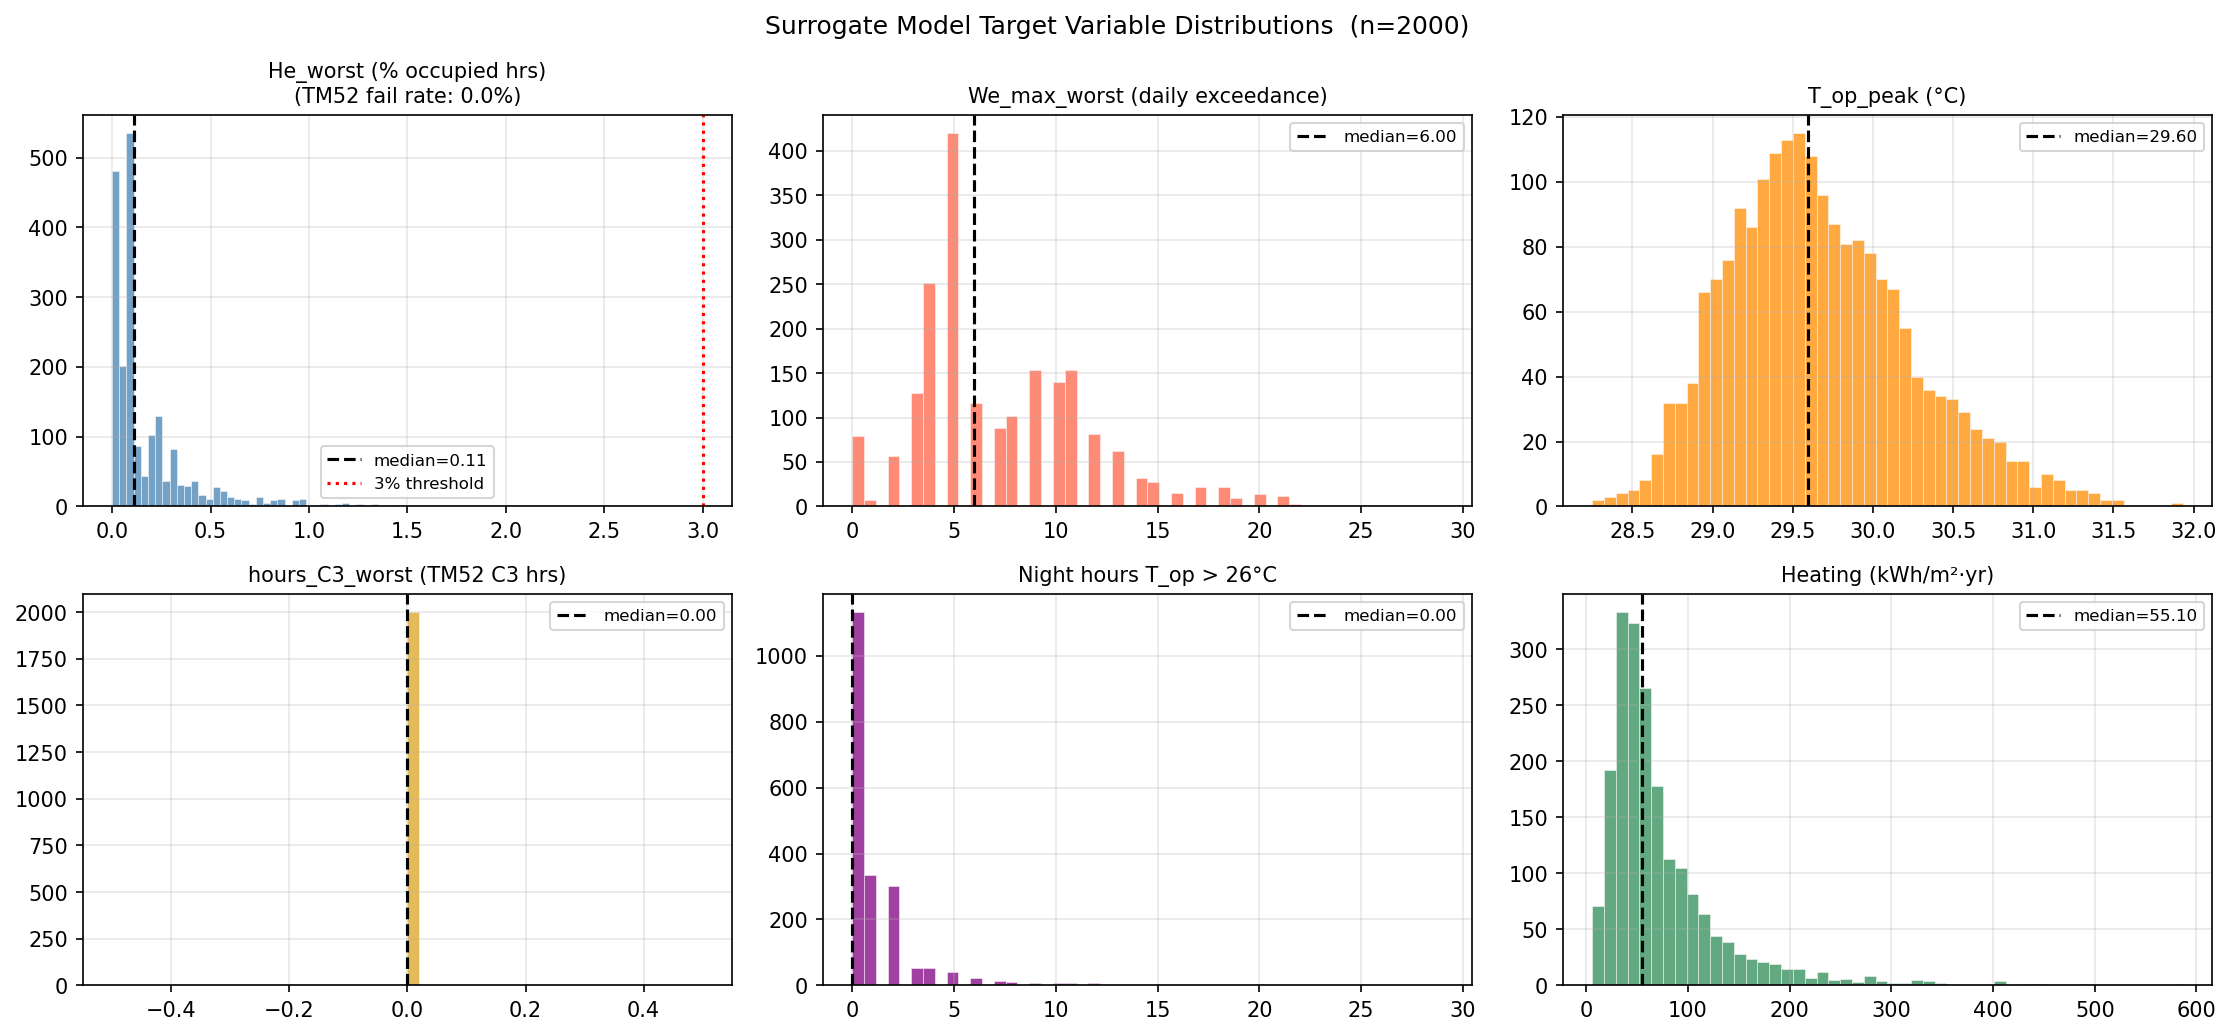


Target correlation matrix:
                  He_worst  We_max_worst  T_op_peak  hours_C3_worst  hours_gt26_night  heat_kWh_m2
He_worst             1.000         0.907      0.886             NaN             0.468        0.507
We_max_worst         0.907         1.000      0.972             NaN             0.357        0.594
T_op_peak            0.886         0.972      1.000             NaN             0.349        0.596
hours_C3_worst         NaN           NaN        NaN             NaN               NaN          NaN
hours_gt26_night     0.468         0.357      0.349             NaN             1.000        0.010
heat_kWh_m2          0.507         0.594      0.596             NaN             0.010        1.000


In [2]:
# ── Cell 1: EDA — Target Distributions ───────────────────────────────────────
from IPython.display import Image, display

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(TARGET_COLS):
    meta = TARGET_META[col]
    vals = df[col].dropna()
    ax = axes[i]
    ax.hist(vals, bins=40, color=meta['color'], alpha=0.88, edgecolor='white', lw=0.4)
    ax.axvline(vals.median(), color='0.2', ls='--', lw=1.2)

    stats_lines = [f"Median = {vals.median():.2f}"]
    if meta['threshold'] is not None:
        ax.axvline(meta['threshold'], color='#B22222', ls=':', lw=1.4)
        fail_rate = 100 * (vals >= meta['threshold']).mean()
        stats_lines.append(f"Fail proxy = {fail_rate:.1f}%")

    ax.text(0.98, 0.96, '\n'.join(stats_lines), transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'))
    ax.set_title(meta['short'])
    ax.set_xlabel(meta['label'])
    ax.set_ylabel('Count')
    ax.grid(alpha=0.25)

p = FIG_IN_TEXT_DIR / f'{HOUSE_TYPE}_target_distributions.png'
savefig(fig, p)
display(Image(str(p)))

print("\nTarget correlation matrix:")
print(df[TARGET_COLS].corr().round(3).to_string())


In [3]:
# ── Cell 2: Train / Validation / Test Split ───────────────────────────────────
X = df[PARAM_COLS].values
y = df[TARGET_COLS].values   # shape (N, 5)

# 70 / 15 / 15  split
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tv, y_tv, test_size=0.15/0.85, random_state=42)

print(f"Train : {X_train.shape[0]:>5}  ({100*X_train.shape[0]/len(X):.0f}%)")
print(f"Val   : {X_val.shape[0]:>5}  ({100*X_val.shape[0]/len(X):.0f}%)")
print(f"Test  : {X_test.shape[0]:>5}  ({100*X_test.shape[0]/len(X):.0f}%)")

Train :  1400  (70%)
Val   :   300  (15%)
Test  :   300  (15%)


In [4]:
# ── Cell 3: XGBoost  (per-target, 5 independent models) ──────────────────────
# XGBoost = gradient boosted decision trees
# • Builds trees sequentially, each tree corrects residuals of the previous
# • Does NOT need feature scaling
# • Naturally handles non-linearity and feature interactions
# • Per-target: 5 separate XGBRegressor instances

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed:  pip install xgboost")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def fit_eval(model, X_tr, y_tr, X_va, y_va, tag):
    model.fit(X_tr, y_tr)
    p = model.predict(X_va)
    r2   = r2_score(y_va, p)
    mae  = mean_absolute_error(y_va, p)
    rmse = mean_squared_error(y_va, p) ** 0.5
    print(f"    {tag:<28}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")
    return model, dict(R2=r2, MAE=mae, RMSE=rmse)

xgb_models = []
rf_models  = []
metrics_xgb = []
metrics_rf  = []

print("XGBoost — per-target training\n")
for i, target in enumerate(TARGET_COLS):
    y_tr = y_train[:, i]
    y_va = y_val[:, i]
    print(f"  [{target}]")

    if HAS_XGB:
        xgb = XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=42, verbosity=0,
        )
        xgb_m, m = fit_eval(xgb, X_train, y_tr, X_val, y_va, 'XGBoost')
        xgb_models.append(xgb_m)
        metrics_xgb.append({**m, 'target': target})

    # RF as baseline comparison
    rf = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                               n_jobs=-1, random_state=42)
    rf_m, m_rf = fit_eval(rf, X_train, y_tr, X_val, y_va, 'RandomForest (baseline)')
    rf_models.append(rf_m)
    metrics_rf.append({**m_rf, 'target': target})
    print()

print("\n── XGBoost Val R² ──")
for m in metrics_xgb:
    print(f"  {m['target']:<25}  R²={m['R2']:.4f}")


XGBoost — per-target training

  [He_worst]


    XGBoost                       R²=0.8819  MAE=0.0448  RMSE=0.0737
    RandomForest (baseline)       R²=0.7489  MAE=0.0726  RMSE=0.1075

  [We_max_worst]


    XGBoost                       R²=0.9197  MAE=0.9501  RMSE=1.2256
    RandomForest (baseline)       R²=0.8175  MAE=1.4364  RMSE=1.8484

  [T_op_peak]


    XGBoost                       R²=0.9495  MAE=0.0987  RMSE=0.1305
    RandomForest (baseline)       R²=0.8284  MAE=0.1900  RMSE=0.2407

  [hours_C3_worst]


    XGBoost                       R²=1.0000  MAE=0.0000  RMSE=0.0000
    RandomForest (baseline)       R²=1.0000  MAE=0.0000  RMSE=0.0000

  [hours_gt26_night]


    XGBoost                       R²=0.6961  MAE=0.4994  RMSE=0.9674
    RandomForest (baseline)       R²=0.6484  MAE=0.6375  RMSE=1.0406

  [heat_kWh_m2]


    XGBoost                       R²=0.8774  MAE=10.2111  RMSE=21.3222
    RandomForest (baseline)       R²=0.7201  MAE=17.3621  RMSE=32.2177


── XGBoost Val R² ──
  He_worst                   R²=0.8819
  We_max_worst               R²=0.9197
  T_op_peak                  R²=0.9495
  hours_C3_worst             R²=1.0000
  hours_gt26_night           R²=0.6961
  heat_kWh_m2                R²=0.8774


Couldn't import dot_parser, loading of dot files will not be possible.


Device: cpu
Parameters: 12,838


  Epoch   1  train=0.77690  val=0.61556  lr=1.00e-03


  Epoch  50  train=0.12208  val=0.09619  lr=1.00e-03


  Epoch 100  train=0.10040  val=0.08558  lr=2.50e-04


  Epoch 150  train=0.09674  val=0.08460  lr=3.13e-05


Early stop at epoch 190  (best val loss=0.08259)

Best val loss = 0.08259


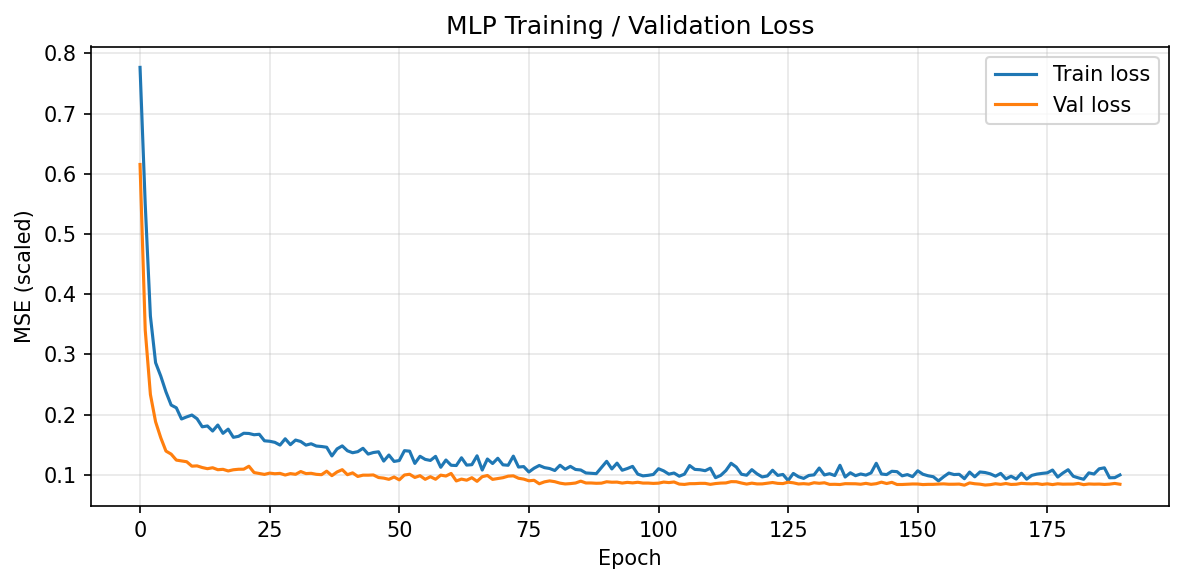


── MLP Val R² per target ──
  He_worst                   R²=0.8670  MAE=0.0497  RMSE=0.0782
  We_max_worst               R²=0.9013  MAE=1.0140  RMSE=1.3590
  T_op_peak                  R²=0.9156  MAE=0.1333  RMSE=0.1688
  hours_C3_worst             R²=0.0000  MAE=0.0000  RMSE=0.0000
  hours_gt26_night           R²=0.7697  MAE=0.4500  RMSE=0.8422
  heat_kWh_m2                R²=0.9393  MAE=8.1539  RMSE=15.0024


In [5]:
# ── Cell 3b: Neural Network (PyTorch MLP, multi-output) ──────────────────────
from IPython.display import Image, display
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_tr_s = scaler_X.fit_transform(X_train)
X_va_s = scaler_X.transform(X_val)
X_te_s = scaler_X.transform(X_test)
y_tr_s = scaler_y.fit_transform(y_train)
y_va_s = scaler_y.transform(y_val)

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32).to(DEVICE)

train_ds = TensorDataset(to_tensor(X_tr_s), to_tensor(y_tr_s))
val_ds   = TensorDataset(to_tensor(X_va_s), to_tensor(y_va_s))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)

class SurrogateMLP(nn.Module):
    def __init__(self, n_in=14, n_out=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,  64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,   32), nn.ReLU(),
            nn.Linear(32,  n_out),
        )
    def forward(self, x):
        return self.net(x)

mlp = SurrogateMLP(n_in=X_train.shape[1], n_out=y_train.shape[1]).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in mlp.parameters()):,}")

optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, min_lr=1e-5)
criterion = nn.MSELoss()

EPOCHS = 300; PATIENCE = 30
best_val = float('inf'); best_state = None; wait = 0
train_losses = []; val_losses = []

for epoch in range(1, EPOCHS + 1):
    mlp.train()
    tl = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward(); optimizer.step()
        tl += loss.item() * len(xb)
    tl /= len(train_ds)

    mlp.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            vl += criterion(mlp(xb), yb).item() * len(xb)
    vl /= len(val_ds)
    train_losses.append(tl); val_losses.append(vl)
    scheduler.step(vl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_state = {k: v.clone() for k, v in mlp.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}  (best val loss={best_val:.5f})")
            break
    if epoch % 50 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3}  train={tl:.5f}  val={vl:.5f}  lr={optimizer.param_groups[0]['lr']:.2e}")

mlp.load_state_dict(best_state)
print(f"\nBest val loss = {best_val:.5f}")

# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_title('MLP Training / Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
p = FIG_APPENDIX_DIR / f'{HOUSE_TYPE}_nn_loss_curve.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.close()
display(Image(str(p)))

mlp.eval()
with torch.no_grad():
    y_va_pred_s = mlp(to_tensor(X_va_s)).cpu().numpy()
y_va_pred = scaler_y.inverse_transform(y_va_pred_s)

metrics_nn = []
print("\n── MLP Val R² per target ──")
for i, target in enumerate(TARGET_COLS):
    r2   = r2_score(y_val[:, i], y_va_pred[:, i])
    mae  = mean_absolute_error(y_val[:, i], y_va_pred[:, i])
    rmse = mean_squared_error(y_val[:, i], y_va_pred[:, i]) ** 0.5
    metrics_nn.append(dict(target=target, R2=r2, MAE=mae, RMSE=rmse))
    print(f"  {target:<25}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

── Test Set R² (higher is better) ──────────────────────────────────────
model                MLP      RF  XGBoost
target                                   
He_worst          0.8787  0.7583   0.8744
T_op_peak         0.9157  0.8212   0.9428
We_max_worst      0.8994  0.7999   0.9166
heat_kWh_m2       0.9377  0.7188   0.9009
hours_C3_worst    0.0000  1.0000   1.0000
hours_gt26_night  0.7053  0.5654   0.7073

── Test Set MAE (lower is better) ──────────────────────────────────────
model                MLP       RF  XGBoost
target                                    
He_worst          0.0523   0.0797   0.0535
T_op_peak         0.1277   0.1960   0.1073
We_max_worst      1.0823   1.5467   0.9771
heat_kWh_m2       9.0995  20.0086  10.7569
hours_C3_worst    0.0000   0.0000   0.0000
hours_gt26_night  0.6363   0.8141   0.6459


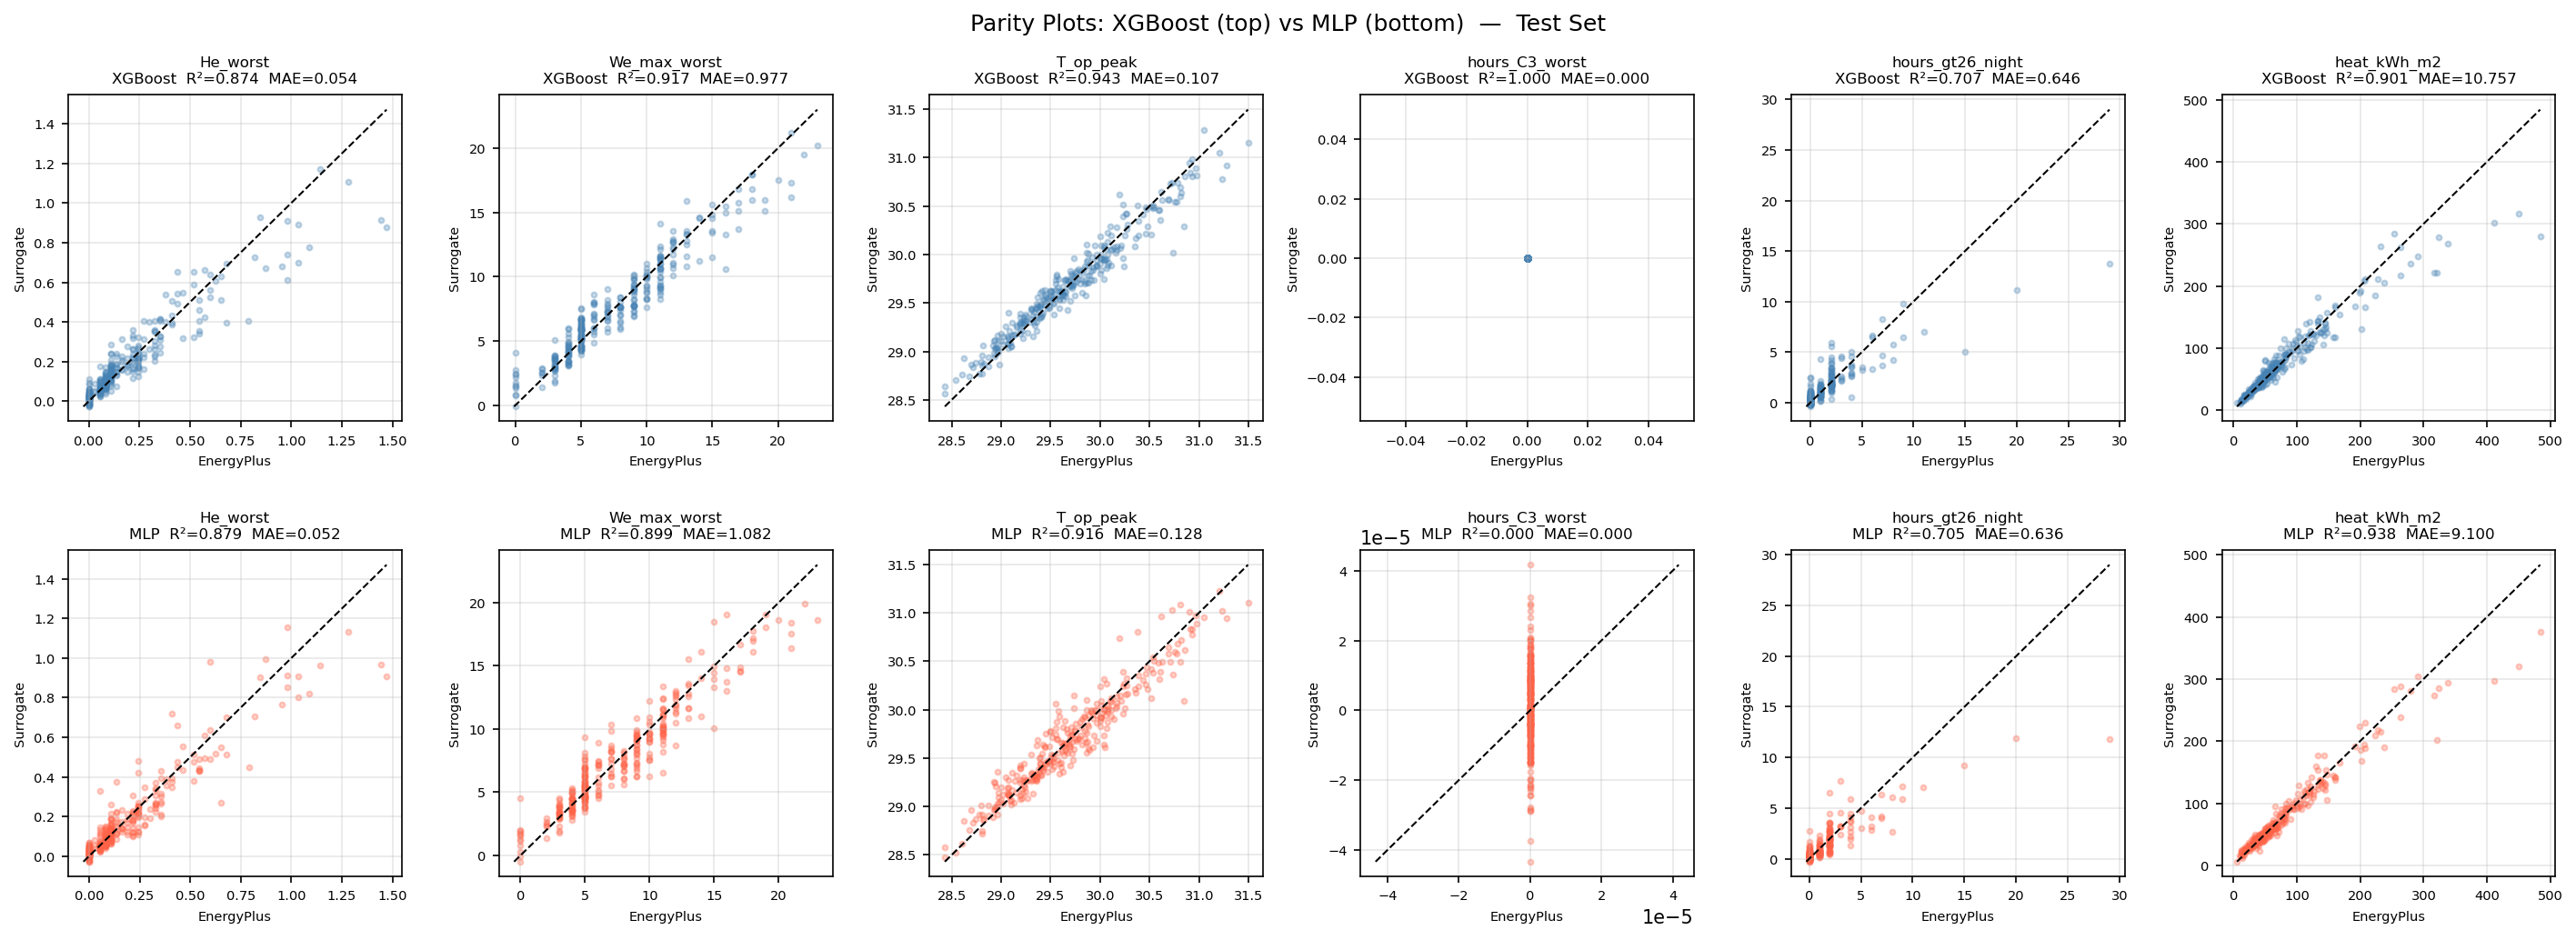

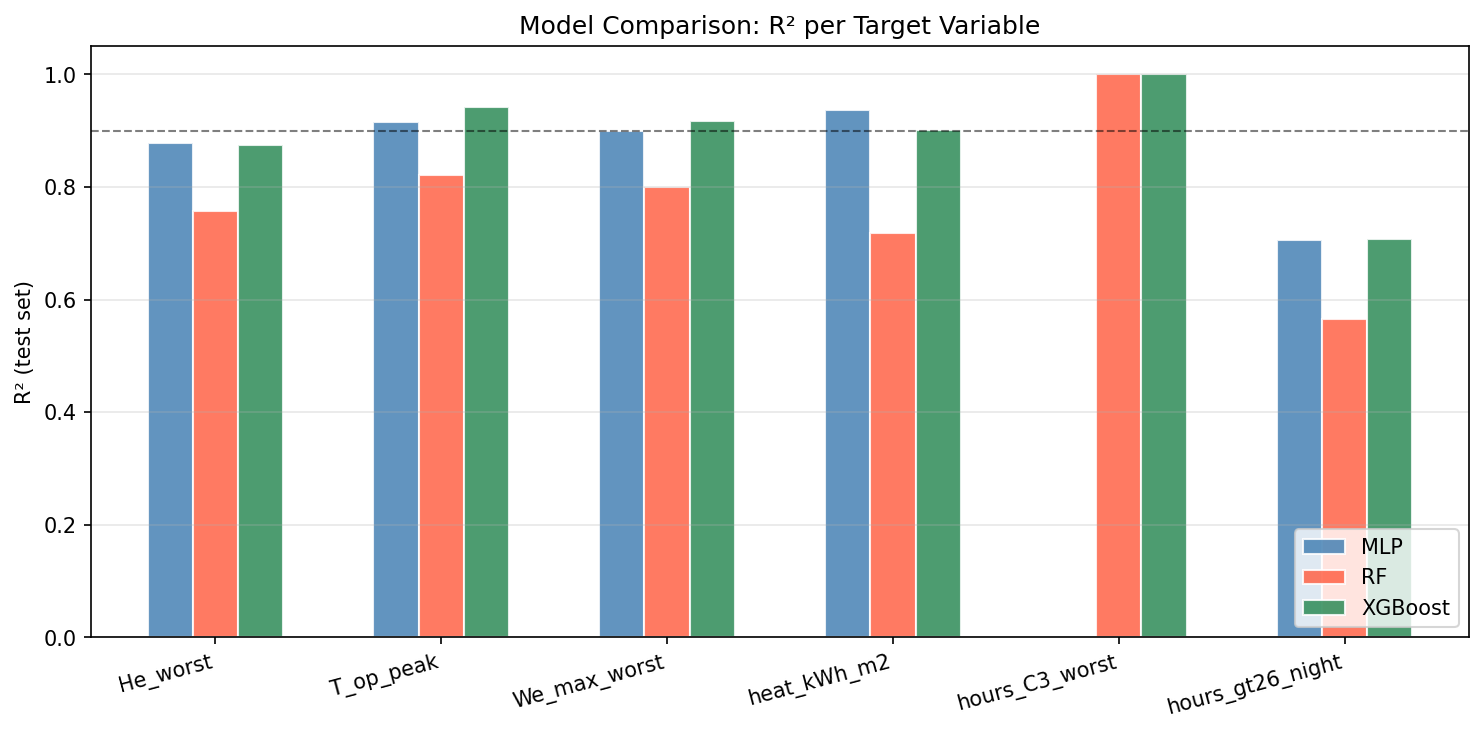

In [6]:
# ── Cell 4: Test Set Comparison — XGBoost vs MLP vs RF ───────────────────────
from IPython.display import Image, display

def predict_nn(model, X_scaled):
    model.eval()
    with torch.no_grad():
        y_s = model(to_tensor(X_scaled)).cpu().numpy()
    return scaler_y.inverse_transform(y_s)

def predict_xgb(models, X):
    return np.column_stack([m.predict(X) for m in models])

def predict_rf(models, X):
    return np.column_stack([m.predict(X) for m in models])

y_pred_xgb = predict_xgb(xgb_models, X_test) if HAS_XGB else None
y_pred_nn  = predict_nn(mlp, X_te_s)
y_pred_rf  = predict_rf(rf_models, X_test)

rows = []
for i, target in enumerate(TARGET_COLS):
    y_true = y_test[:, i]
    for label, y_pred in [('XGBoost', y_pred_xgb), ('MLP', y_pred_nn), ('RF', y_pred_rf)]:
        if y_pred is None:
            continue
        r2   = r2_score(y_true, y_pred[:, i])
        mae  = mean_absolute_error(y_true, y_pred[:, i])
        rmse = mean_squared_error(y_true, y_pred[:, i]) ** 0.5
        rows.append(dict(target=target, model=label, R2=r2, MAE=mae, RMSE=rmse))

test_df = pd.DataFrame(rows)
print("── Test Set R² (higher is better) ──────────────────────────────────────")
print(test_df.pivot(index='target', columns='model', values='R2').round(4).to_string())
print("\n── Test Set MAE (lower is better) ──────────────────────────────────────")
print(test_df.pivot(index='target', columns='model', values='MAE').round(4).to_string())

# Parity plots
fig, axes = plt.subplots(2, len(TARGET_COLS), figsize=(3.2*len(TARGET_COLS), 7))
for i, target in enumerate(TARGET_COLS):
    y_true = y_test[:, i]
    for row_idx, (label, y_pred) in enumerate([
        ('XGBoost', y_pred_xgb),
        ('MLP',     y_pred_nn),
    ]):
        if y_pred is None:
            continue
        r2  = r2_score(y_true, y_pred[:, i])
        mae = mean_absolute_error(y_true, y_pred[:, i])
        ax  = axes[row_idx, i]
        ax.scatter(y_true, y_pred[:, i], alpha=0.35, s=8, color=MODEL_COLORS[label])
        lims = [min(y_true.min(), y_pred[:, i].min()), max(y_true.max(), y_pred[:, i].max())]
        ax.plot(lims, lims, 'k--', lw=1)
        ax.set_title(f"{TARGET_META[target]['short']} | {label}")
        ax.set_xlabel('EnergyPlus')
        ax.set_ylabel('Surrogate')
        ax.tick_params(labelsize=9)
        ax.grid(alpha=0.25)
        ax.text(0.05, 0.95, f"R²={r2:.3f}\nMAE={mae:.3f}", transform=ax.transAxes,
                ha='left', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='0.8'))
p = FIG_PARITY_DIR / f'{HOUSE_TYPE}_parity_xgb_vs_mlp.png'
savefig(fig, p)
display(Image(str(p)))

# R² bar chart
fig2, ax2 = plt.subplots(figsize=(11, 5.5))
r2_pivot = test_df.pivot(index='target', columns='model', values='R2')
r2_pivot = r2_pivot[['RF', 'XGBoost', 'MLP']]
r2_pivot.plot(kind='bar', ax=ax2, width=0.68,
              color=[MODEL_COLORS['RF'], MODEL_COLORS['XGBoost'], MODEL_COLORS['MLP']],
              alpha=0.9, edgecolor='white')
ax2.axhline(0.9, color='black', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('')
ax2.set_ylabel('R² (test set)')
ax2.set_xticklabels([TARGET_META[t]['short'] for t in r2_pivot.index], rotation=15, ha='right')
ax2.legend(loc='lower right', frameon=True)
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0, 1.05)
p2 = FIG_IN_TEXT_DIR / f'{HOUSE_TYPE}_model_comparison_r2.png'
savefig(fig2, p2)
display(Image(str(p2)))

# Export canonical test-prediction table for publication figures
pred_rows = []
for i, target in enumerate(TARGET_COLS):
    y_true = y_test[:, i]
    for label, y_pred in [('XGBoost', y_pred_xgb), ('MLP', y_pred_nn), ('RF', y_pred_rf)]:
        if y_pred is None:
            continue
        pred_rows.append(pd.DataFrame({
            'archetype': HOUSE_TYPE,
            'target': target,
            'model': label,
            'y_true': y_true,
            'y_pred': y_pred[:, i],
        }))
pd.concat(pred_rows, ignore_index=True).to_csv(TEST_PREDICTIONS_CSV, index=False)
print(f"Saved → {TEST_PREDICTIONS_CSV}")


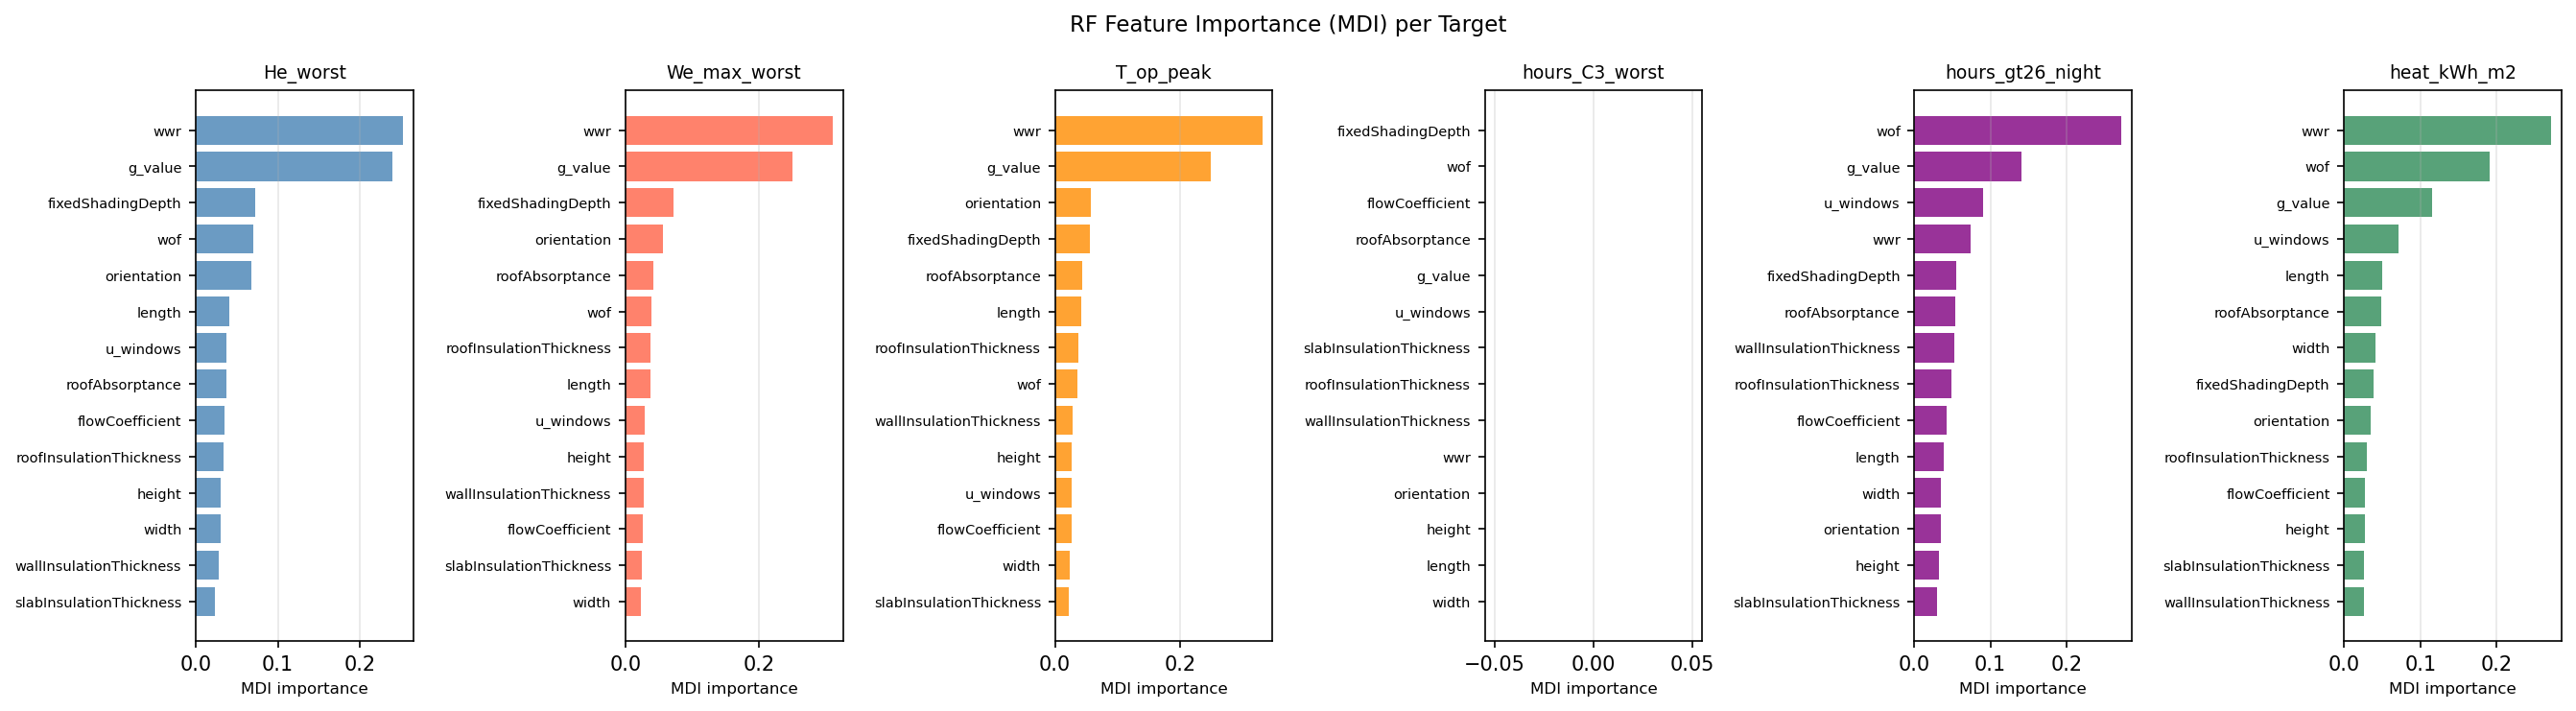

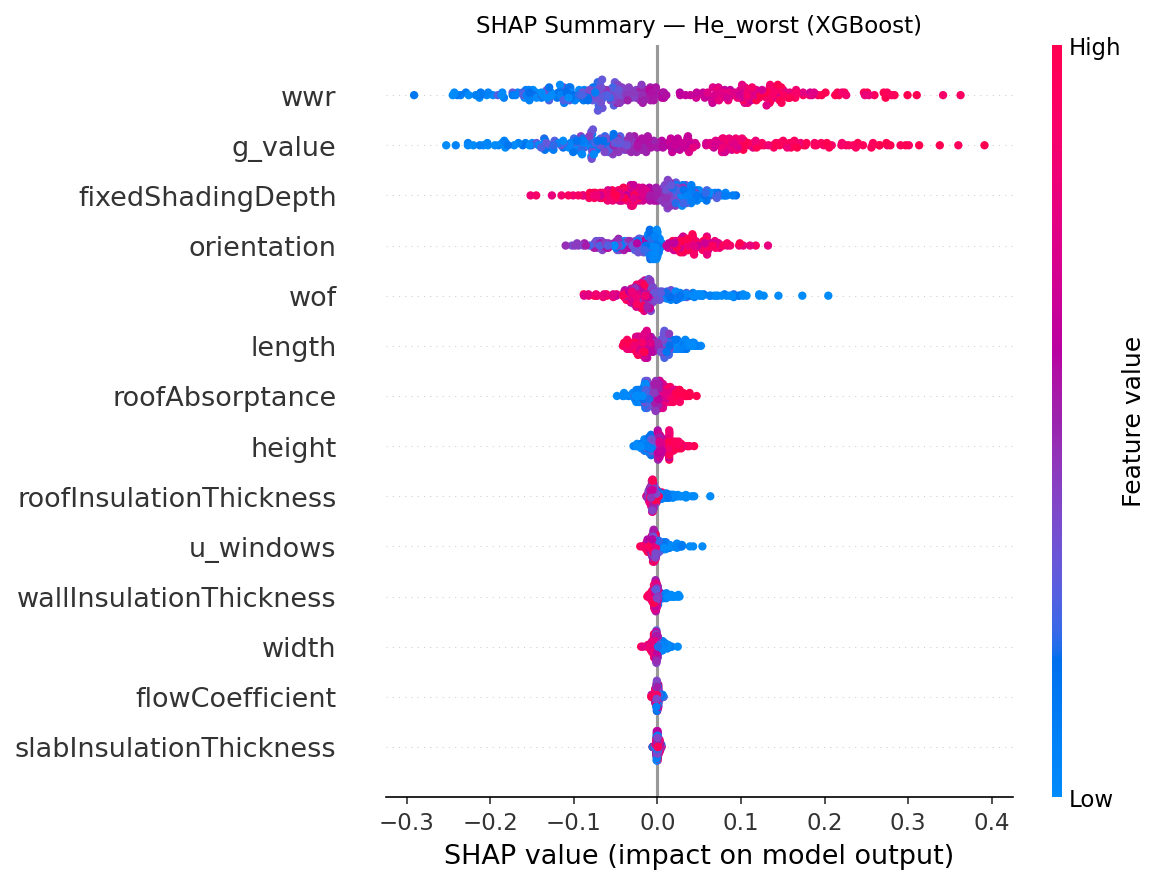

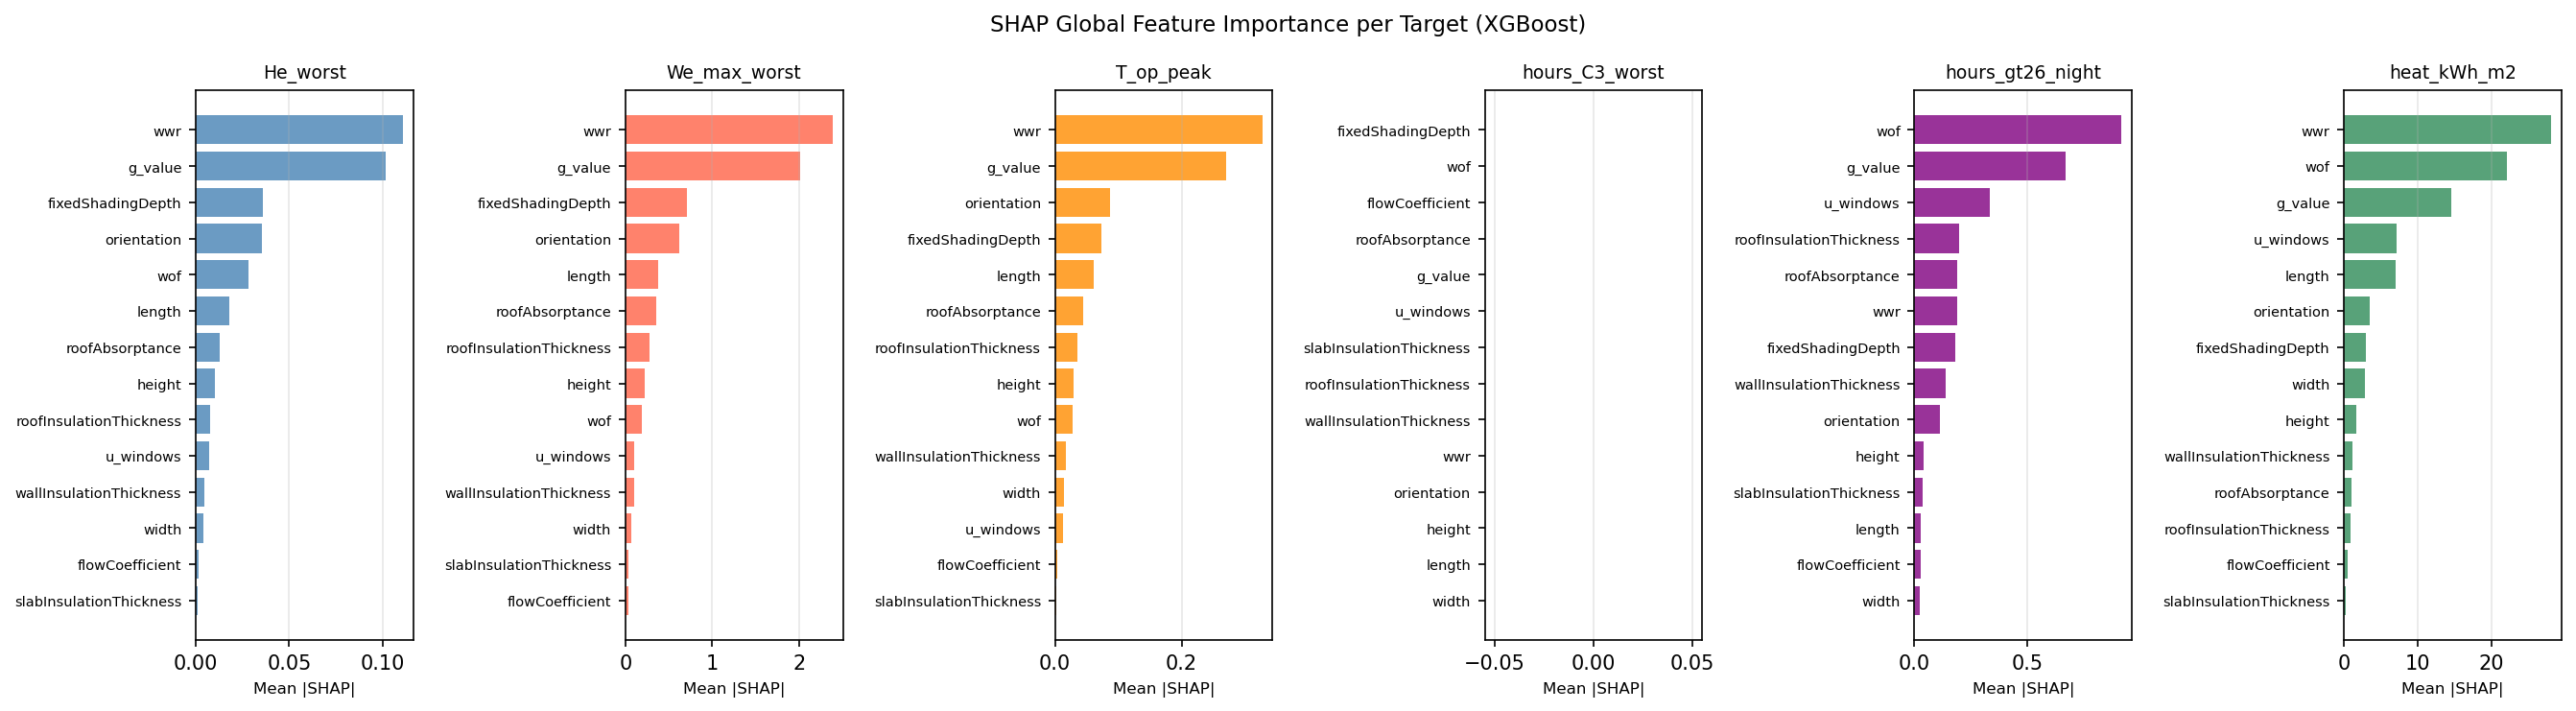

Figures saved → /Users/hlbao/Projects/dissertation/formal model file/output/figures_semi
SHAP analysis complete.


In [7]:
# ── Cell 5: Feature Importance (RF built-in + SHAP) ──────────────────────────
from IPython.display import Image, display

# ── 5a: Random Forest built-in importance (MDI) ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (target, rf_m) in enumerate(zip(TARGET_COLS, rf_models)):
    imp   = rf_m.feature_importances_
    order = np.argsort(imp)[::-1]
    ax = axes[i]
    ax.barh([PARAM_COLS[j] for j in order[::-1]], imp[order[::-1]],
            color=TARGET_META[target]['color'], alpha=0.85)
    ax.set_title(TARGET_META[target]['short'])
    ax.set_xlabel('MDI importance')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(alpha=0.25, axis='x')

p = FIG_APPENDIX_DIR / f'{HOUSE_TYPE}_rf_importance.png'
savefig(fig, p)
display(Image(str(p)))

rf_rows = []
for target, rf_m in zip(TARGET_COLS, rf_models):
    for feature, importance in zip(PARAM_COLS, rf_m.feature_importances_):
        rf_rows.append({
            'archetype': HOUSE_TYPE,
            'target': target,
            'feature': feature,
            'importance': float(importance),
        })
pd.DataFrame(rf_rows).to_csv(RF_IMPORTANCE_CSV, index=False)
print(f"Saved → {RF_IMPORTANCE_CSV}")

# ── 5b: SHAP values via XGBoost TreeExplainer ────────────────────────────────
best_models = xgb_models
model_label = 'XGBoost'

try:
    import shap

    # He_worst beeswarm summary
    target_idx  = TARGET_COLS.index('He_worst')
    explainer   = shap.TreeExplainer(best_models[target_idx])
    shap_vals   = explainer.shap_values(X_test)

    fig_shap, ax_shap = plt.subplots(figsize=(8, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=PARAM_COLS,
                      show=False, plot_size=None)
    plt.tight_layout()
    p = FIG_SHAP_HE_DIR / f'{HOUSE_TYPE}_shap_He_worst.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    display(Image(str(p)))

    beeswarm_rows = []
    for sample_idx in range(X_test.shape[0]):
        for feature_idx, feature in enumerate(PARAM_COLS):
            beeswarm_rows.append({
                'archetype': HOUSE_TYPE,
                'target': 'He_worst',
                'sample_idx': sample_idx,
                'feature': feature,
                'feature_value': float(X_test[sample_idx, feature_idx]),
                'shap_value': float(shap_vals[sample_idx, feature_idx]),
            })
    pd.DataFrame(beeswarm_rows).to_csv(SHAP_BEESWARM_HE_CSV, index=False)
    print(f"Saved → {SHAP_BEESWARM_HE_CSV}")

    # Mean |SHAP| bar chart for all targets
    fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
    axes2 = axes2.flatten()
    shap_rows = []
    for i, (target, model) in enumerate(zip(TARGET_COLS, best_models)):
        sv       = shap.TreeExplainer(model).shap_values(X_test)
        mean_abs = np.abs(sv).mean(axis=0)
        order    = np.argsort(mean_abs)[::-1]
        for feature, value in zip(PARAM_COLS, mean_abs):
            shap_rows.append({
                'archetype': HOUSE_TYPE,
                'target': target,
                'feature': feature,
                'mean_abs_shap': float(value),
            })
        axes2[i].barh([PARAM_COLS[j] for j in order[::-1]], mean_abs[order[::-1]],
                      color=TARGET_META[target]['color'], alpha=0.85)
        axes2[i].set_title(TARGET_META[target]['short'])
        axes2[i].set_xlabel('Mean |SHAP|')
        axes2[i].tick_params(axis='y', labelsize=8)
        axes2[i].grid(alpha=0.25, axis='x')
    p2 = FIG_IN_TEXT_DIR / f'{HOUSE_TYPE}_shap_all_targets.png'
    savefig(fig2, p2)
    display(Image(str(p2)))
    pd.DataFrame(shap_rows).to_csv(SHAP_IMPORTANCE_CSV, index=False)
    print(f"Saved → {SHAP_IMPORTANCE_CSV}")

    print(f"Figures saved → in-text: {FIG_IN_TEXT_DIR}; appendix: {FIG_APPENDIX_DIR}")
    print("SHAP analysis complete.")

except ImportError:
    print("SHAP not installed — install with: pip install shap")
    print("Using RF MDI importance as proxy.")


In [8]:
# ── Cell 5b: Save Performance Metrics to CSV ─────────────────────────────────
perf_rows = []

for row in metrics_xgb:
    perf_rows.append({'model': 'XGBoost', 'split': 'val', **row})
for row in metrics_rf:
    perf_rows.append({'model': 'RF', 'split': 'val', **row})
for row in metrics_nn:
    perf_rows.append({'model': 'MLP', 'split': 'val', **row})
for _, row in test_df.iterrows():
    perf_rows.append({'model': row['model'], 'split': 'test',
                      'target': row['target'], 'R2': row['R2'],
                      'MAE': row['MAE'], 'RMSE': row['RMSE']})

perf_df = pd.DataFrame(perf_rows)[['model', 'split', 'target', 'R2', 'MAE', 'RMSE']]
perf_df.to_csv(PERF_CSV, index=False)
print(f"Saved → {PERF_CSV}\n")

test_r2  = perf_df[perf_df['split']=='test'].pivot(index='target', columns='model', values='R2').round(4)
test_mae = perf_df[perf_df['split']=='test'].pivot(index='target', columns='model', values='MAE').round(4)
print("── Test R² ──")
print(test_r2.to_string())
print("\n── Test MAE ──")
print(test_mae.to_string())

Saved → /Users/hlbao/Projects/dissertation/formal model file/output/model_performance_semi.csv

── Test R² ──
model                MLP      RF  XGBoost
target                                   
He_worst          0.8787  0.7583   0.8744
T_op_peak         0.9157  0.8212   0.9428
We_max_worst      0.8994  0.7999   0.9166
heat_kWh_m2       0.9377  0.7188   0.9009
hours_C3_worst    0.0000  1.0000   1.0000
hours_gt26_night  0.7053  0.5654   0.7073

── Test MAE ──
model                MLP       RF  XGBoost
target                                    
He_worst          0.0523   0.0797   0.0535
T_op_peak         0.1277   0.1960   0.1073
We_max_worst      1.0823   1.5467   0.9771
heat_kWh_m2       9.0995  20.0086  10.7569
hours_C3_worst    0.0000   0.0000   0.0000
hours_gt26_night  0.6363   0.8141   0.6459


In [9]:
# ── Cell 6: Save Models ───────────────────────────────────────────────────────
import pickle

MODEL_DIR.mkdir(exist_ok=True)

if HAS_XGB:
    for target, m in zip(TARGET_COLS, xgb_models):
        with open(MODEL_DIR / f"xgb_{target}.pkl", 'wb') as f:
            pickle.dump(m, f)

for target, m in zip(TARGET_COLS, rf_models):
    with open(MODEL_DIR / f"rf_{target}.pkl", 'wb') as f:
        pickle.dump(m, f)

torch.save(mlp.state_dict(), MODEL_DIR / "mlp_weights.pt")
with open(MODEL_DIR / "mlp_scaler_X.pkl", 'wb') as f:
    pickle.dump(scaler_X, f)
with open(MODEL_DIR / "mlp_scaler_y.pkl", 'wb') as f:
    pickle.dump(scaler_y, f)

best_model_by_target = {}
for target in TARGET_COLS:
    sub = test_df[test_df['target'] == target].set_index('model')['R2']
    best_model_by_target[target] = sub.idxmax()

meta = dict(
    house_type=HOUSE_TYPE,
    param_cols=PARAM_COLS,
    target_cols=TARGET_COLS,
    n_train=X_train.shape[0],
    n_val=X_val.shape[0],
    n_test=X_test.shape[0],
    mlp_architecture='14→128(BN+ReLU+Drop)→64(BN+ReLU+Drop)→32(ReLU)→5',
    best_model_per_target=best_model_by_target,
)
(MODEL_DIR / "metadata.json").write_text(json.dumps(meta, indent=2))

print(f"Saved to: {MODEL_DIR}")
print("Files:", [f.name for f in sorted(MODEL_DIR.iterdir())])
print("\nBest model per target:")
for t, m in best_model_by_target.items():
    print(f"  {t:<25}  →  {m}")

Saved to: /Users/hlbao/Projects/dissertation/formal model file/output/models_semi
Files: ['metadata.json', 'mlp_scaler_X.pkl', 'mlp_scaler_y.pkl', 'mlp_weights.pt', 'rf_He_worst.pkl', 'rf_T_op_peak.pkl', 'rf_We_max_worst.pkl', 'rf_heat_kWh_m2.pkl', 'rf_hours_C3_worst.pkl', 'rf_hours_gt26_night.pkl', 'xgb_He_worst.pkl', 'xgb_T_op_peak.pkl', 'xgb_We_max_worst.pkl', 'xgb_heat_kWh_m2.pkl', 'xgb_hours_C3_worst.pkl', 'xgb_hours_gt26_night.pkl']

Best model per target:
  He_worst                   →  MLP
  We_max_worst               →  XGBoost
  T_op_peak                  →  XGBoost
  hours_C3_worst             →  XGBoost
  hours_gt26_night           →  XGBoost
  heat_kWh_m2                →  MLP
